In [1]:
from torchvision import datasets, transforms
import torch

# Convert image to tensor
transform = transforms.ToTensor()

project_path = "/content/drive/My Drive/Logistic-Softmax-Neural-Nets"
data_path = f"{project_path}/data"

# Load both training and test parts
train_data = datasets.MNIST(
    root=data_path,
    train=True,
    transform=transform,
    download=True
    )
test_data  = datasets.MNIST(
    root=data_path,
    train=False,
    transform=transform,
    download=True
    )

all_data = torch.cat((train_data.data, test_data.data), dim=0)
all_targets = torch.cat((train_data.targets, test_data.targets), dim=0)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 478kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.53MB/s]


In [2]:
from sklearn.model_selection import train_test_split

# add a channel dimension and normalize to [0, 1]
all_data = all_data.unsqueeze(1).float() / 255.0

train_data, temp_data, train_targets, temp_targets = train_test_split(
    all_data,
    all_targets,
    train_size=0.60,
    stratify=all_targets,
    random_state=42
)


val_data, test_data, val_targets, test_targets = train_test_split(
    temp_data,
    temp_targets,
    train_size=0.50,
    stratify=temp_targets,
    random_state=42
)


In [3]:
from torch.utils.data import random_split, DataLoader, TensorDataset

train_dataset = TensorDataset(train_data, train_targets)
val_dataset = TensorDataset(val_data, val_targets)
test_dataset = TensorDataset(test_data, test_targets)

# Create the DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [4]:
import torch.nn as nn

# Define the FeedForward Neural Network
class FeedForwardNN(nn.Module):
    def __init__ (self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.hidden1 = nn.Linear(28*28, 128)
        self.activation = nn.ReLU()
        self.hidden2 = nn.Linear(128, 256)
        self.output = nn.Linear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.activation(self.hidden1(x))
        x = self.activation(self.hidden2(x))
        x = self.output(x)
        return x

In [5]:
# Applying He initialization to the model weights
def initialize_weights(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight, nonlinearity='relu')
        nn.init.zeros_(module.bias)

In [6]:
def train_model(model, train_loader, val_loader, optimizer, loss_fn, device,
                epochs, model_path, patience=3, improvement_threshold=1e-3):

    train_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []

    patience_counter = 0
    best_val_loss = float('inf')

    for epoch in range(epochs):
        # Training Phase
        model.train()

        train_loss_epoch = 0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            # Forward Pass
            outputs = model(inputs)

            # Calculate Loss
            loss = loss_fn(outputs, labels)

            # Compute Gradients
            loss.backward()
            optimizer.step()

            train_loss_epoch += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        # Calculate average training loss and accuracy for the epoch
        avg_train_loss = train_loss_epoch / len(train_loader)
        avg_train_acc = 100 * correct_train / total_train

        train_loss_history.append(avg_train_loss)
        train_acc_history.append(avg_train_acc)

        # Validation Phase
        model.eval()

        val_loss_epoch = 0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = loss_fn(outputs, labels)

                val_loss_epoch += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        avg_val_loss = val_loss_epoch / len(val_loader)
        avg_val_acc = 100 * correct_val / total_val

        val_loss_history.append(avg_val_loss)
        val_acc_history.append(avg_val_acc)

        # Logging
        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}%")
        print(f"  Val Loss:   {avg_val_loss:.4f} | Val Acc:   {avg_val_acc:.2f}%")

        # Early Stopping and saving Checkpoints
        improvement = best_val_loss - avg_val_loss
        if improvement > improvement_threshold:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), model_path)
        else:
            patience_counter += 1
            print(f"  Val loss did not improve by {improvement_threshold:.3f}.")

        if patience_counter >= patience:
            print(f"--- Early stopping after {epoch + 1} epochs ---")
            break
    history = {
        'train_loss': train_loss_history,
        'val_loss': val_loss_history,
        'train_acc': train_acc_history,
        'val_acc': val_acc_history
    }

    return history


In [7]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FeedForwardNN().to(device)
model.apply(initialize_weights)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

model_path = f"{project_path}/model_checkpoint.pth"

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    epochs=100,
    model_path=model_path
)

Epoch [1/100]
  Train Loss: 0.8931 | Train Acc: 76.95%
  Val Loss:   0.4557 | Val Acc:   87.52%
Epoch [2/100]
  Train Loss: 0.3777 | Train Acc: 89.46%
  Val Loss:   0.3446 | Val Acc:   90.47%
Epoch [3/100]
  Train Loss: 0.3093 | Train Acc: 91.22%
  Val Loss:   0.3022 | Val Acc:   91.34%
Epoch [4/100]
  Train Loss: 0.2724 | Train Acc: 92.35%
  Val Loss:   0.2800 | Val Acc:   91.98%
Epoch [5/100]
  Train Loss: 0.2468 | Train Acc: 93.02%
  Val Loss:   0.2532 | Val Acc:   92.76%
Epoch [6/100]
  Train Loss: 0.2264 | Train Acc: 93.65%
  Val Loss:   0.2400 | Val Acc:   93.24%
Epoch [7/100]
  Train Loss: 0.2108 | Train Acc: 94.06%
  Val Loss:   0.2286 | Val Acc:   93.46%
Epoch [8/100]
  Train Loss: 0.1968 | Train Acc: 94.40%
  Val Loss:   0.2156 | Val Acc:   93.80%
Epoch [9/100]
  Train Loss: 0.1855 | Train Acc: 94.75%
  Val Loss:   0.2049 | Val Acc:   94.21%
Epoch [10/100]
  Train Loss: 0.1748 | Train Acc: 95.04%
  Val Loss:   0.1954 | Val Acc:   94.46%
Epoch [11/100]
  Train Loss: 0.1657 | T

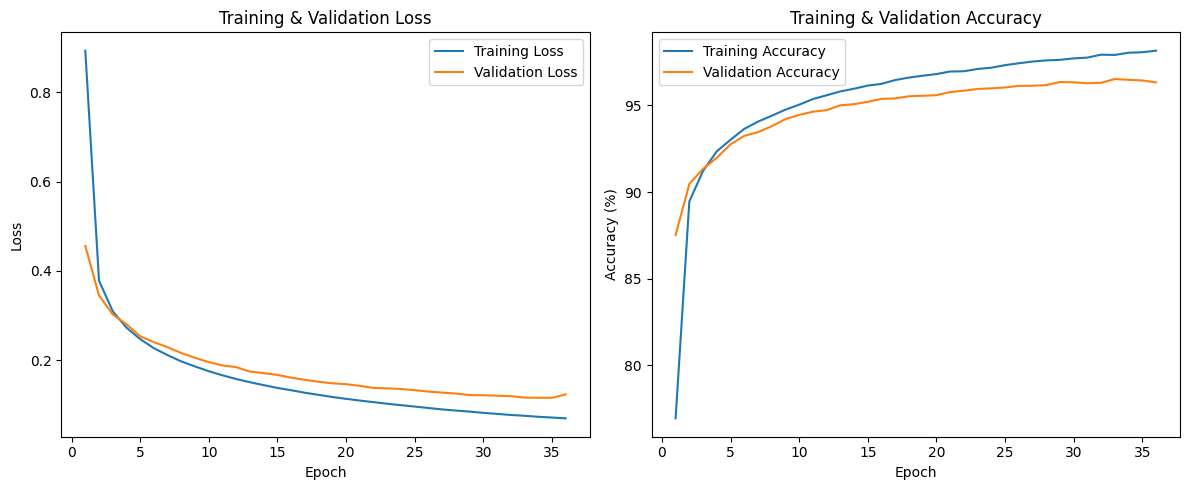

In [8]:
train_loss = history['train_loss']
val_loss = history['val_loss']
train_acc = history['train_acc']
val_acc = history['val_acc']

model.load_state_dict(torch.load(model_path))
epochs_range = range(1, len(train_loss) + 1)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Training & Validation Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Training & Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

## Convergence Analysis :

### **Loss**

* The **training loss** (blue) decreased steadily throughout the training process, indicating that the model was successfully learning from the training data.
* The **validation loss** (red) also decreased overall but exhibited small fluctuations due to the stochastic nature of **mini-batch gradient descent**.

### **Accuracy**

* The **training accuracy** showed a consistent upward trend across epochs.
* The **validation accuracy** improved initially and then **plateaued**.

### **Convergence and Early Stopping**

* The model trained for a total of **49** epochs.
* **Early stopping** was triggered when the **validation loss** failed to improve by more than **0.001** for **3 consecutive epochs** (patience = 3).
* The **best model** was saved from **epoch 49**, representing the point of **optimal convergence** before overfitting began.


In [10]:
N_RUNS = 5

# Store the validation loss from all runs
all_val_loss_histories = []
all_train_loss_histories = []

for i in range(N_RUNS):

    torch.manual_seed(i)

    model = FeedForwardNN().to(device)
    model.apply(initialize_weights)
    optimizer = optim.SGD(model.parameters(), lr=0.001)

    # Temporary lists for this run
    run_train_loss = []
    run_val_loss = []

    for epoch in range(50):
        # Training
        model.train()
        train_loss_epoch = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss_epoch += loss.item()
        run_train_loss.append(train_loss_epoch / len(train_loader))

        # Validation
        model.eval()
        val_loss_epoch = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = loss_fn(outputs, labels)
                val_loss_epoch += loss.item()
        run_val_loss.append(val_loss_epoch / len(val_loader))

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/50, Val Loss: {run_val_loss[-1]:.4f}")

    all_train_loss_histories.append(run_train_loss)
    all_val_loss_histories.append(run_val_loss)

  Epoch 10/50, Val Loss: 0.4304
  Epoch 20/50, Val Loss: 0.3323
  Epoch 30/50, Val Loss: 0.2948
  Epoch 40/50, Val Loss: 0.2703
  Epoch 50/50, Val Loss: 0.2527
  Epoch 10/50, Val Loss: 0.4217
  Epoch 20/50, Val Loss: 0.3283
  Epoch 30/50, Val Loss: 0.2904
  Epoch 40/50, Val Loss: 0.2655
  Epoch 50/50, Val Loss: 0.2472
  Epoch 10/50, Val Loss: 0.4384
  Epoch 20/50, Val Loss: 0.3364
  Epoch 30/50, Val Loss: 0.2964
  Epoch 40/50, Val Loss: 0.2711
  Epoch 50/50, Val Loss: 0.2528
  Epoch 10/50, Val Loss: 0.4421
  Epoch 20/50, Val Loss: 0.3348
  Epoch 30/50, Val Loss: 0.2924
  Epoch 40/50, Val Loss: 0.2658
  Epoch 50/50, Val Loss: 0.2466
  Epoch 10/50, Val Loss: 0.4295
  Epoch 20/50, Val Loss: 0.3379
  Epoch 30/50, Val Loss: 0.2980
  Epoch 40/50, Val Loss: 0.2729
  Epoch 50/50, Val Loss: 0.2530


In [11]:
import numpy as np
# Convert lists of lists to 2D NumPy arrays
train_loss_arr = np.array(all_train_loss_histories)
val_loss_arr = np.array(all_val_loss_histories)

# Calculate mean and std dev across the runs (axis=0)
mean_train_loss = np.mean(train_loss_arr, axis=0)
std_train_loss = np.std(train_loss_arr, axis=0)

mean_val_loss = np.mean(val_loss_arr, axis=0)
std_val_loss = np.std(val_loss_arr, axis=0)

# Create an X-axis for plotting
epochs_range = range(1, 51)

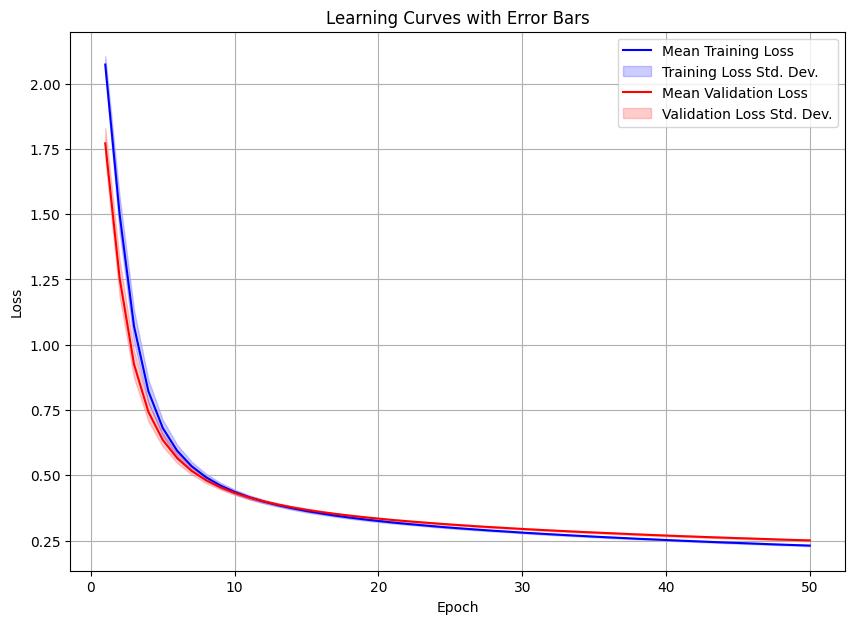

In [12]:
plt.figure(figsize=(10, 7))

# Plot Training Loss
plt.plot(epochs_range, mean_train_loss, 'b-', label='Mean Training Loss')
plt.fill_between(
    epochs_range,
    mean_train_loss - std_train_loss,
    mean_train_loss + std_train_loss,
    color='blue',
    alpha=0.2, # Make the shaded region semi-transparent
    label='Training Loss Std. Dev.'
)

# Plot Validation Loss
plt.plot(epochs_range, mean_val_loss, 'r-', label='Mean Validation Loss')
plt.fill_between(
    epochs_range,
    mean_val_loss - std_val_loss,
    mean_val_loss + std_val_loss,
    color='red',
    alpha=0.2,
    label='Validation Loss Std. Dev.'
)

plt.title('Learning Curves with Error Bars')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# new model with batch norm and Dropout
class FFNN_new(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()

        # Layer 1
        self.hidden1 = nn.Linear(28*28, 128)
        self.bn1 = nn.BatchNorm1d(128)  # BN for hidden1's output

        # Layer 2
        self.hidden2 = nn.Linear(128, 256)
        self.bn2 = nn.BatchNorm1d(256)  # BN for hidden2's output

        self.activation = nn.ReLU()

        self.dropout = nn.Dropout(p=0.2)
        self.output = nn.Linear(256, 10)

    def forward(self, x):
        x = self.flatten(x)

        x = self.hidden1(x)
        x = self.bn1(x)
        x = self.activation(x)
        x = self.dropout(x)

        x = self.hidden2(x)
        x = self.bn2(x)
        x = self.activation(x)
        x = self.dropout(x)

        x = self.output(x)
        return x


In [14]:
import torch.optim as optim

model2 = FFNN_new().to(device)
model2.apply(initialize_weights)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model2.parameters(), lr=0.01)


model_path = f"{project_path}/model_new_checkpoint.pth"

history = train_model(
    model=model2,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    epochs=100,
    model_path=model_path
)

Epoch [1/100]
  Train Loss: 0.8140 | Train Acc: 75.28%
  Val Loss:   0.3684 | Val Acc:   90.06%
Epoch [2/100]
  Train Loss: 0.4193 | Train Acc: 87.63%
  Val Loss:   0.2834 | Val Acc:   92.08%
Epoch [3/100]
  Train Loss: 0.3439 | Train Acc: 89.76%
  Val Loss:   0.2418 | Val Acc:   93.19%
Epoch [4/100]
  Train Loss: 0.3081 | Train Acc: 90.93%
  Val Loss:   0.2137 | Val Acc:   93.89%
Epoch [5/100]
  Train Loss: 0.2737 | Train Acc: 91.71%
  Val Loss:   0.1988 | Val Acc:   94.26%
Epoch [6/100]
  Train Loss: 0.2586 | Train Acc: 92.18%
  Val Loss:   0.1864 | Val Acc:   94.54%
Epoch [7/100]
  Train Loss: 0.2413 | Train Acc: 92.82%
  Val Loss:   0.1762 | Val Acc:   94.70%
Epoch [8/100]
  Train Loss: 0.2268 | Train Acc: 93.01%
  Val Loss:   0.1663 | Val Acc:   95.06%
Epoch [9/100]
  Train Loss: 0.2144 | Train Acc: 93.49%
  Val Loss:   0.1599 | Val Acc:   95.24%
Epoch [10/100]
  Train Loss: 0.2086 | Train Acc: 93.73%
  Val Loss:   0.1531 | Val Acc:   95.36%
Epoch [11/100]
  Train Loss: 0.1992 | T

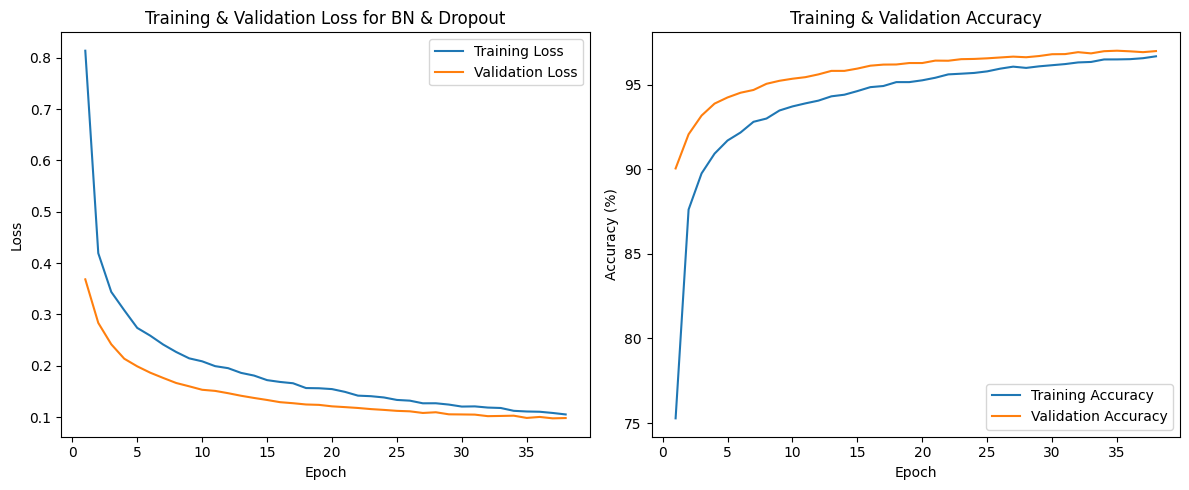

In [17]:
train_loss = history['train_loss']
val_loss = history['val_loss']
train_acc = history['train_acc']
val_acc = history['val_acc']

model2.load_state_dict(torch.load(model_path))
epochs_range = range(1, len(train_loss) + 1)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Training & Validation Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training & Validation Loss for BN & Dropout')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Training & Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
def test_model(model, test_loader, loss_fn, device):
    model.eval()
    test_loss = 0
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)

            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    avg_test_loss = test_loss / len(test_loader)
    avg_test_acc = 100 * correct_test / total_test

    return avg_test_loss, avg_test_acc

In [19]:
ffn_model_path = f"{project_path}/model_checkpoint.pth"
ffn_new_model_path = f"{project_path}/model_new_checkpoint.pth"

from google.colab import drive
drive.mount('/content/drive')

ffn_model = FeedForwardNN().to(device)
ffn_model.load_state_dict(torch.load(ffn_model_path))

ffn_new_model = FFNN_new().to(device)
ffn_new_model.load_state_dict(torch.load(ffn_new_model_path))

ffn_loss, ffn_acc = test_model(ffn_model, test_loader, loss_fn, device)
ffn_new_loss, ffn_new_acc = test_model(ffn_new_model, test_loader, loss_fn, device)

print(f"FeedForward NN: {ffn_acc:.2f}% Accuracy, Loss: {ffn_loss:.3f}")
print(f"FeedForward NN with BN: {ffn_new_acc:.2f}% Accuracy, Loss: {ffn_new_loss:.3f}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FeedForward NN: 96.66% Accuracy, Loss: 0.113
FeedForward NN with BN: 97.20% Accuracy, Loss: 0.092
